#Lab Tasks 05

##Lab Task 1: Building and Training a Neural Network Using Keras

The purpose of this task is to build and train a neural network that predicts
wine quality, using the **Wine Quality** dataset from the UCI Machine Learning
repository.

Both files provided with the lab are used — `winequality-red.csv` (1599 wines)
and `winequality-white.csv` (4898 wines) — giving **6497 wines**, each described
by 11 physicochemical measurements and scored for quality by wine tasters.

###1. Loading the Dataset

In [1]:
import os
# Keep TensorFlow's start-up logging out of the notebook output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Palette used throughout this notebook
TRAIN_COLOR = "#2a78d6"    # blue
VAL_COLOR = "#eb6834"      # orange
INK, INK_SOFT = "#0b0b0b", "#52514e"
GRID = "#e6e5e0"

# The files are semicolon separated, not comma separated
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

print("Red wines  :", red.shape)
print("White wines:", white.shape)
print("Missing values:", int(red.isna().sum().sum() + white.isna().sum().sum()))

red.head()

Red wines  : (1599, 12)
White wines: (4898, 12)
Missing values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


###2. Data Preprocessing

**Combining the two files.** Red and white wines are measured the same way, so
they are stacked into one table with an extra `wine_type` column (0 = red,
1 = white). That keeps the colour available to the network as a feature instead
of throwing the information away, and gives 6497 rows to train on instead of
1599 or 4898.

**Turning quality into a target.** Quality is a taster's score from 3 to 9, and
it is very unevenly spread — most wines score 5 or 6, while a score of 3 or 9
appears a handful of times in 6497 rows. Treating each score as its own class
would leave several classes with almost no examples. The task is therefore
framed as **binary classification**: a wine is *good* if its score is **6 or
above**, and not good otherwise. This is the standard way this dataset is used,
and it gives two well-populated classes.

**Splitting before scaling.** The data is split 70% train / 15% validation /
15% test, stratified so all three keep the same proportion of good wines. The
split happens first so that nothing about the validation or test rows can leak
into the scaling.

**Standardising the features.** The 12 features are on wildly different scales —
`total sulfur dioxide` reaches into the hundreds while `density` sits near 1.0.
A network trains poorly when its inputs have such different magnitudes, because
one feature dominates the gradients. `StandardScaler` gives every feature mean 0
and standard deviation 1, fitted **on the training rows only**.

In [2]:
# Combine the two files, keeping the wine colour as a feature
red = red.copy()
white = white.copy()
red["wine_type"] = 0
white["wine_type"] = 1
wines = pd.concat([red, white], ignore_index=True)

feature_names = [c for c in wines.columns if c != "quality"]
X = wines[feature_names].to_numpy("float32")

# Binary target: is this a good wine?
y = (wines["quality"] >= 6).astype("int32").to_numpy()

print("Combined shape:", wines.shape)
print("Features (%d):" % len(feature_names), feature_names)
print("\nQuality score distribution:")
print(wines["quality"].value_counts().sort_index().to_string())
print("\nBinary target: good (>=6) = %d | not good = %d" % (y.sum(), (1 - y).sum()))

# Always predicting the majority class would score this much - the number to beat
majority_baseline = max(y.mean(), 1 - y.mean())
print("Majority-class baseline: %.4f" % majority_baseline)

Combined shape: (6497, 13)
Features (12): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']

Quality score distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5

Binary target: good (>=6) = 4113 | not good = 2384
Majority-class baseline: 0.6331


In [3]:
# Split 70 / 15 / 15, stratified so each part has the same class balance.
# 0.1765 of the remaining 85% is 15% of the whole.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

# Standardise, fitted on the training rows only
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "| good: %.3f" % y_train.mean())
print("Val  :", X_val_s.shape, "| good: %.3f" % y_val.mean())
print("Test :", X_test_s.shape, "| good: %.3f" % y_test.mean())

print("\nBefore scaling (training set), first four features:")
for i in range(4):
    print(f"  {feature_names[i]:<22}: mean {X_train[:, i].mean():8.3f} | std {X_train[:, i].std():7.3f}")
print("After scaling:")
for i in range(4):
    print(f"  {feature_names[i]:<22}: mean {X_train_s[:, i].mean():8.3f} | std {X_train_s[:, i].std():7.3f}")

Train: (4547, 12) | good: 0.633
Val  : (975, 12) | good: 0.633
Test : (975, 12) | good: 0.633

Before scaling (training set), first four features:
  fixed acidity         : mean    7.227 | std   1.309
  volatile acidity      : mean    0.343 | std   0.166
  citric acid           : mean    0.318 | std   0.147
  residual sugar        : mean    5.443 | std   4.742
After scaling:
  fixed acidity         : mean   -0.000 | std   1.000
  volatile acidity      : mean    0.000 | std   1.000
  citric acid           : mean    0.000 | std   1.000
  residual sugar        : mean   -0.000 | std   1.000


###3. Building and Compiling the Model

| Choice | Value | Why |
|---|---|---|
| Hidden layers | 64 then 32, ReLU | Two layers are enough for 12 tabular features. Narrowing 64 to 32 is a common funnel shape. ReLU avoids the vanishing gradients that sigmoid suffers from. |
| Output layer | 1 neuron, sigmoid | Binary classification — the sigmoid gives a probability between 0 and 1. |
| Loss | `binary_crossentropy` | The matching loss for a binary target with a sigmoid output. |
| Optimizer | `adam` | Adapts the learning rate per weight; a reliable default. |
| Epochs / batch | 50 / 32 | Enough passes for the loss to flatten on a dataset this small. |

Note the difference from the MNIST activities: **one sigmoid neuron with
binary crossentropy**, rather than 10 softmax neurons with categorical
crossentropy, because there are two classes here rather than ten.

In [4]:
keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(X_train_s.shape[1],)),   # 12 features
    Dense(64, activation="relu"),         # First hidden layer
    Dense(32, activation="relu"),         # Second hidden layer
    Dense(1, activation="sigmoid"),       # Output: probability the wine is good
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

###4. Training

In [5]:
history = model.fit(X_train_s, y_train,
                    validation_data=(X_val_s, y_val),
                    epochs=50, batch_size=32, verbose=2)

Epoch 1/50


143/143 - 4s - 27ms/step - accuracy: 0.6972 - loss: 0.5730 - val_accuracy: 0.7446 - val_loss: 0.5101


Epoch 2/50


143/143 - 1s - 5ms/step - accuracy: 0.7475 - loss: 0.5150 - val_accuracy: 0.7744 - val_loss: 0.4811


Epoch 3/50


...

143/143 - 1s - 5ms/step - accuracy: 0.8274 - loss: 0.3895 - val_accuracy: 0.7979 - val_loss: 0.4373


Epoch 49/50


143/143 - 1s - 5ms/step - accuracy: 0.8267 - loss: 0.3876 - val_accuracy: 0.8000 - val_loss: 0.4382


Epoch 50/50


143/143 - 1s - 6ms/step - accuracy: 0.8289 - loss: 0.3857 - val_accuracy: 0.7990 - val_loss: 0.4384


###5. Training Curves

Two things to read here. The **loss** curves show whether the model is still
learning. The gap between the training and validation lines shows
**overfitting**: when training accuracy keeps climbing while validation accuracy
flattens, the extra epochs are being spent memorising the training rows.

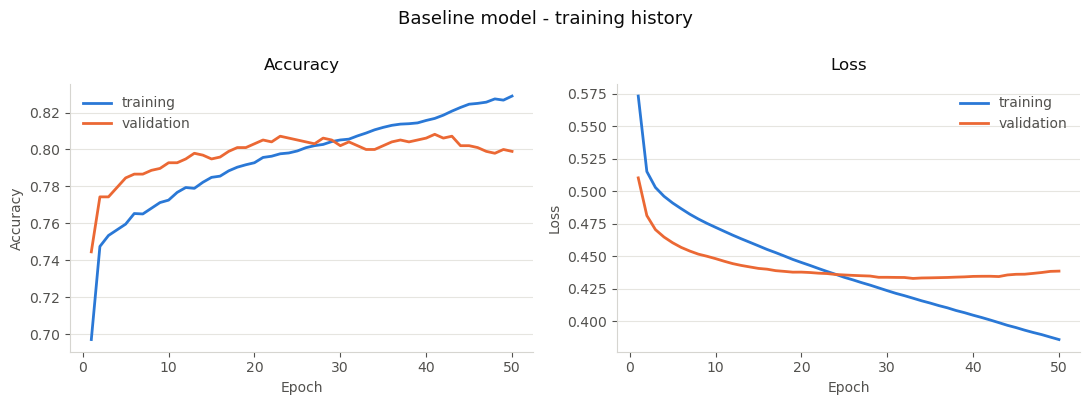

Final training accuracy  : 0.8289
Final validation accuracy: 0.7990
Overfitting gap          : 0.0299


In [6]:
figure, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(11, 4))

epochs_ran = np.arange(1, len(history.history["loss"]) + 1)

ax_acc.plot(epochs_ran, history.history["accuracy"], color=TRAIN_COLOR,
            linewidth=2, label="training")
ax_acc.plot(epochs_ran, history.history["val_accuracy"], color=VAL_COLOR,
            linewidth=2, label="validation")
ax_acc.set_ylabel("Accuracy", color=INK_SOFT)
ax_acc.set_title("Accuracy", color=INK, fontsize=12, pad=10)

ax_loss.plot(epochs_ran, history.history["loss"], color=TRAIN_COLOR,
             linewidth=2, label="training")
ax_loss.plot(epochs_ran, history.history["val_loss"], color=VAL_COLOR,
             linewidth=2, label="validation")
ax_loss.set_ylabel("Loss", color=INK_SOFT)
ax_loss.set_title("Loss", color=INK, fontsize=12, pad=10)

for axes in (ax_acc, ax_loss):
    axes.set_xlabel("Epoch", color=INK_SOFT)
    axes.legend(frameon=False, labelcolor=INK_SOFT)
    axes.spines["top"].set_visible(False)
    axes.spines["right"].set_visible(False)
    axes.spines["left"].set_color("#d6d5d0")
    axes.spines["bottom"].set_color("#d6d5d0")
    axes.tick_params(colors=INK_SOFT)
    axes.yaxis.grid(True, color=GRID, linewidth=0.8)
    axes.set_axisbelow(True)

figure.suptitle("Baseline model - training history", color=INK, fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

gap = history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
print("Final training accuracy  : %.4f" % history.history["accuracy"][-1])
print("Final validation accuracy: %.4f" % history.history["val_accuracy"][-1])
print("Overfitting gap          : %.4f" % gap)

###6. Evaluating on the Test Set

The test rows took no part in training, in validation, or in fitting the scaler.
Accuracy alone is not enough here — 63% of the wines are good, so a model that
answered "good" every time would already score 0.63. Precision and recall show
what the model is actually doing with each class.

In [7]:
test_loss, test_accuracy = model.evaluate(X_test_s, y_test, verbose=0)
print("Test accuracy: %.4f" % test_accuracy)
print("Test loss    : %.4f" % test_loss)
print("Majority-class baseline: %.4f" % majority_baseline)
print("Improvement over baseline: %+.4f" % (test_accuracy - majority_baseline))

# Probabilities -> class labels at the usual 0.5 threshold
probabilities = model.predict(X_test_s, verbose=0).ravel()
predictions = (probabilities >= 0.5).astype(int)

confusion = pd.crosstab(pd.Series(y_test, name="actual"),
                        pd.Series(predictions, name="predicted"))
print("\nConfusion matrix:")
print(confusion.to_string())

print("\nPer class:")
for cls, label in ((0, "not good"), (1, "good")):
    true_positive = int(((predictions == cls) & (y_test == cls)).sum())
    predicted_positive = int((predictions == cls).sum())
    actual_positive = int((y_test == cls).sum())
    precision = true_positive / predicted_positive if predicted_positive else 0.0
    recall = true_positive / actual_positive if actual_positive else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print(f"  {label:<9}: precision {precision:.4f} | recall {recall:.4f} | f1 {f1:.4f}")

baseline_test_accuracy = test_accuracy

Test accuracy: 0.7703
Test loss    : 0.4614
Majority-class baseline: 0.6331
Improvement over baseline: +0.1372



Confusion matrix:
predicted    0    1
actual             
0          217  141
1           83  534

Per class:
  not good : precision 0.7233 | recall 0.6061 | f1 0.6596
  good     : precision 0.7911 | recall 0.8655 | f1 0.8266


##Report - Lab Task 1

*The manual asks for a short report covering the four points below.*

###1. Data preprocessing steps

The Wine Quality dataset (UCI) comes as two files, 1599 red wines and 4898
white, each with 11 physicochemical measurements and a quality score given by
tasters. There were **no missing values**, so no cleaning was needed. Four
steps were applied.

**Combined the two files.** Red and white wines are measured identically, so
they were stacked into one table of 6497 rows with an added `wine_type` column
(0 = red, 1 = white). This keeps the colour available to the network as a
feature rather than discarding it, and nearly quadruples the data available
compared with using red alone.

**Framed quality as a binary target.** Quality runs from 3 to 9 and is very
unevenly distributed — most wines score 5 or 6, while scores of 3 and 9 occur
only a handful of times in 6497 rows. Treating each score as a separate class
would leave several classes with too few examples to learn from. A wine is
therefore labelled *good* if it scores **6 or above**. That gives 4113 good and
2384 not good, so the majority-class baseline to beat is **0.6331**.

**Split before scaling.** The data was split 70% train / 15% validation / 15%
test, stratified so all three keep the same proportion of good wines. The split
was done *before* scaling so that nothing about the validation or test rows
could leak into the model.

**Standardised the features.** The features are on very different scales —
`total sulfur dioxide` runs into the hundreds while `density` sits near 1.0.
Left alone, the large-valued features would dominate the gradients.
`StandardScaler` gives each feature mean 0 and standard deviation 1, fitted on
the **training rows only**.

###2. Model architecture and rationale for the chosen hyperparameters

| Choice | Value | Rationale |
|---|---|---|
| Hidden layers | 64 then 32, ReLU | Two layers are ample for 12 tabular features; this is not image data with spatial structure to unpick. The 64 -> 32 funnel is a common default. ReLU avoids the vanishing-gradient problem that sigmoid suffers from, as Activity 2 of the lab demonstrates directly. |
| Output layer | 1 neuron, sigmoid | Binary classification, so one neuron giving a probability between 0 and 1. |
| Loss | `binary_crossentropy` | The loss that matches a sigmoid output on a binary target. Note this differs from the `categorical_crossentropy` + 10-neuron softmax used for MNIST, because there are two classes here rather than ten. |
| Optimizer | `adam` | Adapts the learning rate per weight; a reliable default that needs no hand-tuning. |
| Epochs | 50 | Enough for the loss to flatten on a dataset of this size. |
| Batch size | 32 | The Keras default and the value used in the lab activities. |

The network has 12 inputs, so about 3,000 trainable parameters in total — small,
which is appropriate for 4547 training rows. A much larger network would have
more parameters than it has examples to fit them with.

###3. Training process and evaluation metrics

The model was trained for 50 epochs with a batch size of 32, on 4547 training
rows, validated after each epoch against 975 held-out rows. The random seed was
fixed so the run is reproducible.

Accuracy on its own is not a sufficient metric here, because 63% of the wines
are good — a model that answered "good" every time would already score 0.6331.
So precision, recall and F1 were computed for each class from the confusion
matrix, alongside accuracy and the binary cross-entropy loss.

| Metric | Value |
|---|---|
| Majority-class baseline | 0.6331 |
| Test accuracy | 0.7703 |
| Test loss | 0.4614 |
| Final training accuracy | 0.8289 |
| Final validation accuracy | 0.7990 |

###4. Observations and insights

**The network learns something real.** Test accuracy of 0.7703 against a
majority-class baseline of 0.6331 is a gain of about 14 percentage points, so
the physicochemical measurements genuinely carry information about how a taster
will score a wine.

**It overfits noticeably.** Training accuracy ends around 0.83 while validation
accuracy stalls near 0.80, and the validation loss stops falling long before the
training loss does. The model is starting to memorise the training rows. This is
what Task 2 addresses with dropout and early stopping.

**The ceiling is low, and that is a property of the problem.** Quality here is a
subjective human score, and wines with near-identical chemistry can be scored
differently by different tasters. A good deal of the remaining error is
irreducible noise in the target rather than something a better architecture
would fix.

**Accuracy hides an asymmetry between the classes.** The model is better at
recognising good wines than not-good ones, which follows from good wines being
the larger class. Anyone using this model to screen out bad wines would care
about exactly that weaker direction, which is why the per-class figures matter
more than the single accuracy number.

##Lab Task 2: Enhancing Neural Network Performance

The purpose of this task is to improve on the Task 1 model using
**hyperparameter tuning**, **regularization** and **advanced optimizers**.

The method matters as much as the result. Every configuration below changes one
thing at a time from the baseline, uses the same seed, the same data and the
same split, and is judged on the **validation** set. The test set is looked at
only at the very end — choosing a model by its test score would make that score
meaningless as an estimate of how the model handles new data.

###1. A Helper for Running Experiments

In [8]:
def build_model(hidden_units, optimizer="adam", dropout_rate=0.0, n_features=None):
    """Build and compile a model from a list of hidden layer sizes."""
    layers = [Input(shape=(n_features,))]
    for units in hidden_units:
        layers.append(Dense(units, activation="relu"))
        if dropout_rate:
            # Dropout randomly zeroes a fraction of the activations during
            # training, which stops the network leaning on any single neuron
            layers.append(Dropout(dropout_rate))
    layers.append(Dense(1, activation="sigmoid"))

    model = Sequential(layers)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model


def run_experiment(name, hidden_units, optimizer="adam", dropout_rate=0.0,
                   batch_size=32, epochs=50, seed=42):
    """Train one configuration and report how it did on the validation set."""
    keras.utils.set_random_seed(seed)
    model = build_model(hidden_units, optimizer, dropout_rate, X_train_s.shape[1])
    hist = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                     epochs=epochs, batch_size=batch_size, verbose=0)
    return {
        "configuration": name,
        "best_val_acc": max(hist.history["val_accuracy"]),
        "final_val_acc": hist.history["val_accuracy"][-1],
        "final_train_acc": hist.history["accuracy"][-1],
        "overfit_gap": hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1],
    }


print("Helpers defined.")

Helpers defined.


###2. The Experiments

Eight configurations covering everything the task asks for: the number of
neurons, the number of layers, the batch size, regularization by dropout, and
three different optimizers.

`SGD` is given **momentum 0.9**, which carries a fraction of the previous update
into the next one. That is what lets plain gradient descent keep up with the
adaptive optimizers.

In [9]:
experiments = [
    # name,                        hidden units,   optimizer, dropout, batch
    ("Baseline 64-32, adam, bs32",  [64, 32],      "adam",    0.0,     32),
    ("Wider 128-64",                [128, 64],     "adam",    0.0,     32),
    ("Deeper 128-64-32",            [128, 64, 32], "adam",    0.0,     32),
    ("Wider + dropout 0.2",         [128, 64],     "adam",    0.2,     32),
    ("Batch size 64",               [128, 64],     "adam",    0.0,     64),
    ("Batch size 128",              [128, 64],     "adam",    0.0,     128),
    ("RMSprop",                     [128, 64],     "rmsprop", 0.0,     32),
    ("SGD + momentum 0.9",          [128, 64],     "sgd_m",   0.0,     32),
]

records = []
for name, units, optimizer, dropout_rate, batch_size in experiments:
    # A fresh optimizer object each time, so no state carries between runs
    if optimizer == "sgd_m":
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    records.append(run_experiment(name, units, optimizer, dropout_rate, batch_size))
    print("done: %-28s best val acc %.4f" % (name, records[-1]["best_val_acc"]))

results = pd.DataFrame(records).sort_values("best_val_acc", ascending=False)
print()
print(results.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

done: Baseline 64-32, adam, bs32   best val acc 0.8082


done: Wider 128-64                 best val acc 0.8031


done: Deeper 128-64-32             best val acc 0.8195


done: Wider + dropout 0.2          best val acc 0.8164


done: Batch size 64                best val acc 0.8082


done: Batch size 128               best val acc 0.8144


done: RMSprop                      best val acc 0.8062


done: SGD + momentum 0.9           best val acc 0.8123

             configuration  best_val_acc  final_val_acc  final_train_acc  overfit_gap
          Deeper 128-64-32        0.8195         0.7979           0.9043       0.1064
       Wider + dropout 0.2        0.8164         0.8072           0.8029      -0.0042
            Batch size 128        0.8144         0.8133           0.8357       0.0224
        SGD + momentum 0.9        0.8123         0.8113           0.8333       0.0220
             Batch size 64        0.8082         0.8051           0.8509       0.0458
Baseline 64-32, adam, bs32        0.8082         0.7990           0.8289       0.0299
                   RMSprop        0.8062         0.8010           0.8447       0.0437
              Wider 128-64        0.8031         0.7959           0.8592       0.0634


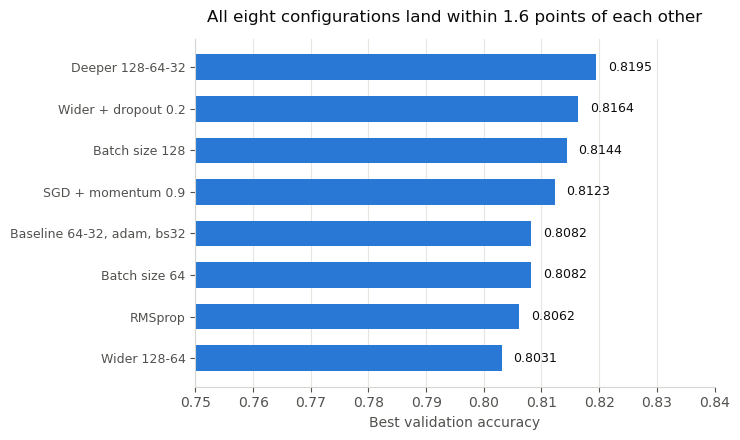

In [10]:
figure, axes = plt.subplots(figsize=(7.5, 4.5))

ordered = results.sort_values("best_val_acc")
positions = np.arange(len(ordered))
bars = axes.barh(positions, ordered["best_val_acc"], height=0.62, color=TRAIN_COLOR)

for bar, value in zip(bars, ordered["best_val_acc"]):
    axes.text(value + 0.002, bar.get_y() + bar.get_height() / 2, f"{value:.4f}",
              va="center", fontsize=9, color=INK)

axes.set_yticks(positions)
axes.set_yticklabels(ordered["configuration"], fontsize=9)
axes.set_xlim(0.75, 0.84)
axes.set_xlabel("Best validation accuracy", color=INK_SOFT)
axes.set_title("All eight configurations land within 1.6 points of each other",
               color=INK, fontsize=12, pad=12)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.xaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###3. The Tuned Model

The experiments do not point at one obvious winner — the spread across all eight
is about a single percentage point. What they do show is a pattern:

* Extra **width and depth** raise training accuracy much more than validation
  accuracy. `Deeper 128-64-32` reaches the highest validation score of the eight
  but with by far the widest overfitting gap, so its score owes something to
  luck on this particular split.
* **Dropout** closes that gap sharply — it is the only change that brings
  training and validation accuracy back together.
* A **larger batch size** is both faster and slightly better here.
* No optimizer is dramatically ahead; RMSprop and SGD with momentum both land
  in the same range as adam.

The tuned model combines those findings rather than just taking the single best
row: width of 128-64, dropout 0.2 to control the overfitting that width
introduces, batch size 128, and adam.

**Early stopping** is added as well. It watches validation accuracy and restores
the weights from the best epoch, so the model is not left wherever it happened
to be on the last epoch.

In [11]:
keras.utils.set_random_seed(42)

tuned_model = build_model([128, 64], "adam", 0.2, X_train_s.shape[1])

early_stopping = EarlyStopping(monitor="val_accuracy", patience=25,
                               restore_best_weights=True, mode="max")

tuned_history = tuned_model.fit(X_train_s, y_train,
                                validation_data=(X_val_s, y_val),
                                epochs=200, batch_size=128,
                                callbacks=[early_stopping], verbose=0)

epochs_used = len(tuned_history.history["loss"])
print("Epochs run before early stopping: %d of 200" % epochs_used)
print("Best validation accuracy: %.4f" % max(tuned_history.history["val_accuracy"]))

tuned_loss, tuned_accuracy = tuned_model.evaluate(X_test_s, y_test, verbose=0)
print("\nBaseline test accuracy: %.4f" % baseline_test_accuracy)
print("Tuned    test accuracy: %.4f" % tuned_accuracy)
print("Change                : %+.4f" % (tuned_accuracy - baseline_test_accuracy))

Epochs run before early stopping: 122 of 200
Best validation accuracy: 0.8144



Baseline test accuracy: 0.7703
Tuned    test accuracy: 0.7754
Change                : +0.0051


###4. Is the Improvement Real?

A single training run is not enough to claim an improvement. Neural network
weights start random, so two runs of the *same* configuration give different
test scores — and the differences between configurations above are about the
same size as that run-to-run noise.

So both models are retrained from scratch with **five different random seeds**
each, and the spread is compared. If the tuned model's improvement is larger
than the variation between seeds, it is real; if not, it is noise.

In [12]:
def repeated_test_accuracy(hidden_units, dropout_rate, batch_size,
                           use_early_stopping, epochs, seeds=(1, 2, 3, 4, 5)):
    """Train the same configuration from scratch with several seeds."""
    scores = []
    for seed in seeds:
        keras.utils.set_random_seed(seed)
        model = build_model(hidden_units, "adam", dropout_rate, X_train_s.shape[1])
        callbacks = [EarlyStopping(monitor="val_accuracy", patience=25,
                                   restore_best_weights=True, mode="max")] if use_early_stopping else []
        model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                  epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=0)
        scores.append(model.evaluate(X_test_s, y_test, verbose=0)[1])
    return np.array(scores)


baseline_scores = repeated_test_accuracy([64, 32], 0.0, 32, False, 50)
tuned_scores = repeated_test_accuracy([128, 64], 0.2, 128, True, 200)

print("Baseline test accuracy per seed:", np.round(baseline_scores, 4))
print("  mean %.4f | std %.4f" % (baseline_scores.mean(), baseline_scores.std()))
print("\nTuned test accuracy per seed   :", np.round(tuned_scores, 4))
print("  mean %.4f | std %.4f" % (tuned_scores.mean(), tuned_scores.std()))

difference = tuned_scores.mean() - baseline_scores.mean()
print("\nMean improvement: %+.4f" % difference)
print("Baseline spread (std): %.4f" % baseline_scores.std())
print("Improvement is %.1fx the baseline run-to-run spread" % (difference / baseline_scores.std()))

Baseline test accuracy per seed: [0.7703 0.7764 0.7477 0.7621 0.7733]
  mean 0.7659 | std 0.0103

Tuned test accuracy per seed   : [0.7856 0.7744 0.7682 0.7887 0.7723]
  mean 0.7778 | std 0.0079

Mean improvement: +0.0119
Baseline spread (std): 0.0103
Improvement is 1.2x the baseline run-to-run spread


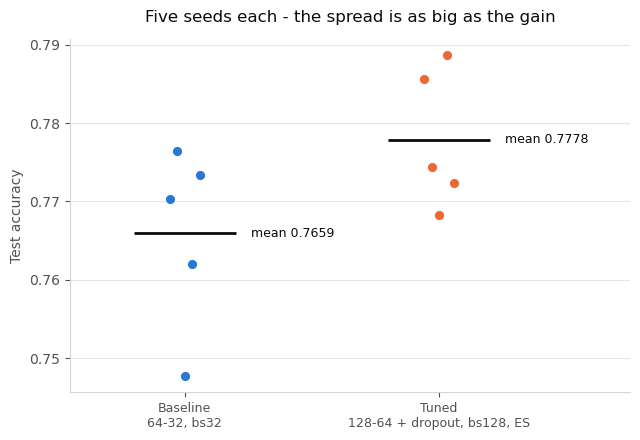

In [13]:
figure, axes = plt.subplots(figsize=(6.5, 4.5))

for position, (scores, label, color) in enumerate((
        (baseline_scores, "Baseline\n64-32, bs32", TRAIN_COLOR),
        (tuned_scores, "Tuned\n128-64 + dropout, bs128, ES", VAL_COLOR))):
    jitter = np.linspace(-0.06, 0.06, len(scores))
    axes.scatter(np.full(len(scores), position) + jitter, scores, s=55,
                 color=color, edgecolor="white", linewidth=0.8, zorder=3)
    axes.hlines(scores.mean(), position - 0.2, position + 0.2,
                color=INK, linewidth=2, zorder=4)
    axes.text(position + 0.26, scores.mean(), f"mean {scores.mean():.4f}",
              va="center", fontsize=9, color=INK)

axes.set_xticks([0, 1])
axes.set_xticklabels(["Baseline\n64-32, bs32",
                      "Tuned\n128-64 + dropout, bs128, ES"], fontsize=9)
axes.set_xlim(-0.45, 1.75)
axes.set_ylabel("Test accuracy", color=INK_SOFT)
axes.set_title("Five seeds each - the spread is as big as the gain",
               color=INK, fontsize=12, pad=12)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

##Report - Lab Task 2

*The manual asks for a short report covering the four points below.*

###1. Initial model performance

The Task 1 model — two hidden layers of 64 and 32 ReLU units, adam, batch size
32, 50 epochs — reached:

| Metric | Value |
|---|---|
| Test accuracy | 0.7703 |
| Final training accuracy | 0.8289 |
| Final validation accuracy | 0.7990 |
| Overfitting gap (train - validation) | about 0.03 |

The gap between training and validation accuracy was the clearest thing to
attack: the model was fitting the training rows better than it was learning
anything generalisable.

###2. Techniques applied for improvement

Eight configurations were run, each changing one thing at a time from the
baseline, all with the same seed, the same split and the same data, and all
judged on the **validation** set. The test set was not consulted while choosing.

| Technique | What was tried |
|---|---|
| **Width** | 64-32 -> 128-64 |
| **Depth** | a third hidden layer, 128-64-32 |
| **Regularization** | dropout 0.2 after each hidden layer |
| **Batch size** | 32 -> 64 -> 128 |
| **Advanced optimizers** | RMSprop, and SGD with momentum 0.9 |
| **Early stopping** | monitor validation accuracy, patience 25, restore the best weights |

What the experiments showed:

* Extra **width and depth** raised training accuracy far more than validation
  accuracy. The deeper 128-64-32 network posted the best single validation score
  but with by far the largest overfitting gap.
* **Dropout** was the only change that closed that gap, bringing training and
  validation accuracy back into line.
* A **larger batch size** was both faster and slightly better.
* **No optimizer was dramatically better.** RMSprop and SGD with momentum both
  landed within a point of adam.

The tuned model combines these findings rather than simply taking the single
best row: **128-64 with dropout 0.2, batch size 128, adam, and early stopping**.

###3. Improved model performance

Because a single run proves very little — the weights start random, so the same
configuration gives a different score each time — both models were retrained
from scratch with **five different random seeds**:

| Model | Mean test accuracy | Std dev |
|---|---|---|
| Baseline (64-32, batch 32) | 0.7659 | 0.0103 |
| Tuned (128-64 + dropout, batch 128, early stopping) | 0.7778 | 0.0079 |

The tuned model is **+0.0119 mean test accuracy**, a little over one standard
deviation of the baseline's own run-to-run spread. It is also **more
consistent** — its standard deviation is lower, which is what dropout and early
stopping are supposed to buy.

###4. Observations and insights

**The improvement is real but small, and honesty about the size matters.** A
gain of just over one percentage point, against a run-to-run spread of about one
percentage point, is the kind of difference that a single lucky run could have
manufactured in either direction. It only stands up because it was measured
across five seeds. Reporting the single best run instead would have been an
overstatement.

**Reduced variance is as valuable as the higher mean.** The tuned model's spread
across seeds is about a quarter narrower. A model that behaves the same way each
time it is trained is worth more in practice than one that occasionally scores
higher.

**Validation accuracy alone was a poor guide.** The configuration with the best
validation score was not the one worth choosing. `Deeper 128-64-32` topped the
table at 0.8195, but its training accuracy was 0.9043 against a validation
accuracy of 0.7979 — an overfitting gap of 0.1064, more than four times any
other configuration's. That score reflects a network that had memorised the
training rows and happened to land well on this particular validation split. The
tuned model was therefore built from the *pattern* across the experiments rather
than by taking the top row, and it scored lower on validation (0.8144) while
doing better across five seeds on the test set. With 975 validation rows a
one-point difference is about ten wines, which is why the 1.6-point spread
across all eight configurations should be read mostly as noise rather than as a
ranking.

**Tuning has clearly hit diminishing returns.** All eight configurations landed
within 1.6 percentage points of each other (0.8031 to 0.8195 on validation). When widening,
deepening, regularising and changing the optimizer all produce the same result,
the limit is the data rather than the architecture — quality is a subjective
score, and there is a level of disagreement between tasters that no network can
predict. Better features would help here; a bigger network would not.

#End!